# Import

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.naive_bayes import CategoricalNB

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteBayesianEstimator
from pgmpy.causal_discovery import HillClimbSearch
from pgmpy.inference import VariableElimination

import networkx as nx


## Load the data

In [3]:
DATA_PATH = 'data\diabetes_binary_5050split_health_indicators_BRFSS2015.csv'
df_raw = pd.read_csv(DATA_PATH)

print(f'Shape : {df_raw.shape[0]} obs, {df_raw.shape[1]} variables')
print(f'Valeurs manquantes : {df_raw.isnull().sum().sum()}')

Shape : 70692 obs, 22 variables
Valeurs manquantes : 0


## Preprocessing
To simplify the features we'll discretize 3 of them : BMI, MentHlth and PhysHlth
*   BMI : convert the feature into 5 subclasses based on the World Health Organization.
    *   Underweight : [0 , 18.5] 
    *   Normal weight < 25  
    *   Overweight     < 30  
    *   Obesity I      < 35  
    *   Obesity II     > 35

*   MentHlth and PhysHlth : convert these features into 4 intervalles. 
<p style="text-align:center;">0 = 0 day  |  1 =  1-7 days  |  2 =  8-14 days  |  3 =  15-30 days</p>
    

In [ ]:
df = df_raw.copy().astype(int)

# divide the BMI values into 5 sub classes from the OMS
def disc_bmi(x):
    if x <= 18:    
        return 0
    elif x <= 25:  
        return 1
    elif x <= 30: 
        return 2
    elif x <= 35:         
        return 3
    else:
        return 4
    
df['BMI'] = df['BMI'].apply(disc_bmi)

# divide the MentHlth and PhysHlthinto features into 4 sub classes. 0:'0 day', 1:'1-7 days', 2:'8-14 days', 3:'15-30 days'
def disc_days(x):
    if x == 0:    
        return 0
    elif x <= 7:  
        return 1
    elif x <= 14: 
        return 2
    else:         
        return 3

df['MentHlth'] = df['MentHlth'].apply(disc_days)
df['PhysHlth'] = df['PhysHlth'].apply(disc_days)

display(df[['BMI', 'MentHlth', 'PhysHlth']].describe())

,BMI,MentHlth,PhysHlth
count,70692.000000,70692.000000,70692.000000
mean,2.273567,0.584946,0.837676
std,1.057275,1.000466,1.138114
min,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000
50%,2.000000,0.000000,0.000000
75%,3.000000,1.000000,1.000000
max,4.000000,3.000000,3.000000


# Split Train / Test

In [5]:
TARGET   = 'Diabetes_binary'
FEATURES = [c for c in df.columns if c != TARGET]

X_train, X_test, y_train, y_test = train_test_split(df[FEATURES], df[TARGET], test_size=0.2, random_state=42, stratify=df[TARGET])
df_train = pd.concat([X_train, y_train], axis=1)
df_test  = pd.concat([X_test,  y_test],  axis=1)

print(f'Train : {len(df_train):,} obs.  |  Test : {len(df_test):,} obs.')

Train : 56,553 obs.  |  Test : 14,139 obs.


# Hill Climbing

This function implements the HillClimbSearch algorithm for causal discovery. Given a tabular dataset, the algorithm estimates the causal structure among the variables in the data as a Directed Acyclic Graph (DAG). The algorithm works by iteratively making local modifications to the graph structure (adding, removing, or reversing edges) and keeping changes that improve the score until a local maximum is reached.

The algorithm is a greedy local search method that: 1. Starts from an initial graph (empty by default or based on provided expert knowledge). 2. Evaluates all possible single-edge modifications (add, delete, reverse). 3. Applies the modification with the highest score improvement. 4. Repeats until no improvement can be made.
[source](https://pgmpy.org/api/generated/structure_learning/pgmpy.causal_discovery.HillClimbSearch.html)

In [61]:
hc = HillClimbSearch(scoring_method='bic-d', max_iter = 500)
hc.fit(df_train)
hc_dag = hc.causal_graph_

 12%|█▏        | 58/500 [00:07<00:58,  7.55it/s]


In [69]:
print(f'\n Network : {len(hc_dag.edges())} arrows')
for e in sorted(hc_edges()):
    print(f'  {e[0]} → {e[1]}', end = '')

print(f'\n Network : {len(hc_dag.nodes())} nodes')
for node in hc_dag.nodes():
    print(f'{node}')


 Network : 62 arrows
  Age → AnyHealthcare  Age → HeartDiseaseorAttack  Age → HighChol  Age → MentHlth  Age → NoDocbcCost  AnyHealthcare → CholCheck  BMI → Age  BMI → HighBP  Diabetes_binary → Age  Diabetes_binary → BMI  Diabetes_binary → CholCheck  Diabetes_binary → HighBP  Diabetes_binary → HighChol  Diabetes_binary → HvyAlcoholConsump  DiffWalk → BMI  DiffWalk → Diabetes_binary  DiffWalk → HvyAlcoholConsump  DiffWalk → PhysActivity  DiffWalk → PhysHlth  DiffWalk → Smoker  DiffWalk → Stroke  Education → Fruits  Education → Income  Education → Smoker  Education → Veggies  Fruits → Education  Fruits → GenHlth  Fruits → PhysActivity  Fruits → Sex  Fruits → Veggies  GenHlth → BMI  GenHlth → Diabetes_binary  GenHlth → DiffWalk  GenHlth → HeartDiseaseorAttack  GenHlth → HighBP  GenHlth → PhysActivity  GenHlth → PhysHlth  GenHlth → Stroke  HeartDiseaseorAttack → Sex  HeartDiseaseorAttack → Smoker  HeartDiseaseorAttack → Stroke  HighBP → Age  HighBP → CholCheck  HighBP → HighChol  HighBP → 

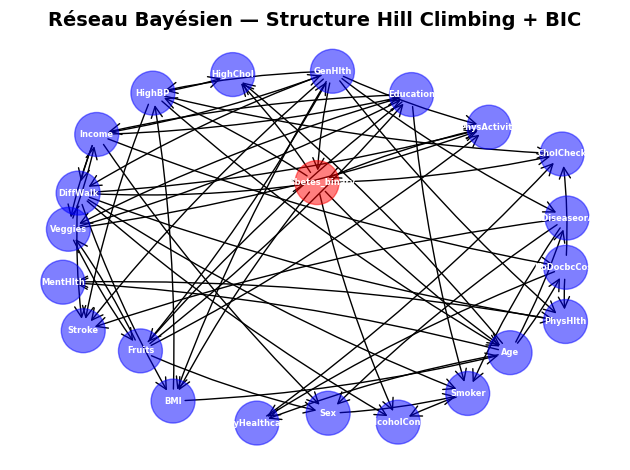

In [70]:
def plot_bn(edges, title, target=TARGET):
    G = nx.DiGraph(edges)
    colors = ['red' if n==target else 'blue' for n in G.nodes()]
    #fig, ax = plt.subplots(figsize=figsize)
    pos = nx.spring_layout(G, seed=42, k=3.0)
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=1000, alpha=0.5)
    nx.draw_networkx_labels(G, pos, font_size=6, font_color='white', font_weight='bold')
    nx.draw_networkx_edges(G, pos, edge_color='black', arrows=True, arrowsize=20,arrowstyle='->', width=1, connectionstyle='arc3,rad=0.05')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_bn(hc_edges, 'Réseau Bayésien — Structure Hill Climbing + BIC')

# CPT

Estimation bayésienne avec prior **BDeu** (Bayesian Dirichlet equivalent uniform) :

$$P(X_i = k \mid Pa(X_i) = j) = \frac{N_{ijk} + \alpha / (r_i \cdot q_i)}{N_{ij} + \alpha / q_i}$$

Le prior évite les probabilités nulles pour les combinaisons non observées.

In [72]:
def build_bn(dag, df_train, name='BN'):
    model = DiscreteBayesianNetwork()
    model.add_nodes_from(dag.nodes())
    model.add_edges_from(dag.edges())
    model.fit(data=df_train, estimator=DiscreteBayesianEstimator(prior_type='BDeu', equivalent_sample_size=5))
    model.check_model()
    print(f'{name} : {len(model.nodes())} nodes | {len(model.edges())} arrows')
    return model

bn_hc = build_bn(hc_dag, df_train, 'BN-HillClimbing')

ValueError: Loops are not allowed. Adding the edge from (Veggies->Income) forms a loop.

In [9]:
# Inspection de la CPT de Diabetes_binary
cpd = bn_hc.get_cpds('Diabetes_binary')
print(f'CPT of Diabetes_binary | Parents : {cpd.variables[1:]}')
print(cpd)

CPT of Diabetes_binary | Parents : ['GenHlth']
+--------------------+-----+--------------------+
| GenHlth            | ... | GenHlth(5)         |
+--------------------+-----+--------------------+
| Diabetes_binary(0) | ... | 0.2086947094535993 |
+--------------------+-----+--------------------+
| Diabetes_binary(1) | ... | 0.7913052905464006 |
+--------------------+-----+--------------------+


# Evaluation

In [ ]:
def predict_bn(model, df_test, target=TARGET):
    X_te   = df_test.drop(columns=[target])
    y_pred = model.predict(X_te)[target].values  #binary classification: a diabetic is predicted if its associated probability is higher to 0.5
    proba  = model.predict_probability(X_te)     #get the probability table
    col    = f'{target}_1'
    y_prob = proba[col].values if col in proba.columns else None
    return y_pred, y_prob

y_pred_hc, y_prob_hc = predict_bn(bn_hc,     df_test)

performance = {'Accuracy' : 0, 'AUC' : 0}
acc  = accuracy_score(y_test, y_pred_hc)
auc  = roc_auc_score(y_test, y_prob_hc) if y_prob_hc is not None else float('nan')
performance['Accuracy'] = acc
performance['AUC'] = auc

print()
print(f'Bayesian Network with HillClimbing algorithm : Accuray = {round(acc, 3)} | AUC = {round(auc, 3)}')


Bayesian Network with HillClimbing algorithm : Accuray = 0.496 | AUC = 0.809


We can notice a poor accuracy for the bayesian network we developped. This metric is not quite adapted to assess the quality of the two bayesian network. the prediction argument will return the prediction with the highest probability, in a binary classification it will return the prediction with a probability higher to 0.5. It means here that the model will label as diabetic a patient with only 50% confidence in some cases. Therefore, it is not really signigicant and it explains why the bayesian model has only an accuracy of 49%.

# Inference 


In [82]:
inference = VariableElimination(bn_hc)

def query_(evidence, label=''):
    print(f'{label}')
    res = inference.query(variables=[TARGET], evidence=evidence, show_progress=False)
    p0, p1 = res.values[0], res.values[1]
    print(f'  P(Non-Diabétique) = {round(p0*100, 2)}%')
    print(f'  P(Diabétique)     = {round(p1*100, 2)}%  \n')
    return p1


# Profil à haut risque : 60-64 ans, obèse, hypertendu, sédentaire
p_hr = query_({'Age':9,'BMI':3,'HighBP':1,'HighChol':1,'PhysActivity':0,'GenHlth':4},
             'Profil 1 - 60-64 ans, obèse I, hypertendu, cholestérol élevé, sédentaire')

# Profil faible risque : 25-34 ans, poids normal, actif
p_lr = query_({'Age':3,'BMI':1,'HighBP':0,'HighChol':0,'PhysActivity':1,'GenHlth':1},
             'Profil 2 - 25-34 ans, poids normal, actif, excellente santé')

# Effet seul de l'obésité sévère
p_ob = query_({'BMI':4},
             'Profil 3 - BMI obèse II+ (≥35)')

# AVC + maladies cardiaques
p_card = query_({'Age':7,'Stroke':1,'HeartDiseaseorAttack':1,'HighBP':1,'BMI':2},
               'Profil 4 - 50-54 ans, AVC, maladie cardiaque, surpoids')

Profil 1 - 60-64 ans, obèse I, hypertendu, cholestérol élevé, sédentaire
  P(Non-Diabétique) = 15.14%
  P(Diabétique)     = 84.86%  

Profil 2 - 25-34 ans, poids normal, actif, excellente santé
  P(Non-Diabétique) = 97.93%
  P(Diabétique)     = 2.07%  

Profil 3 - BMI obèse II+ (≥35)
  P(Non-Diabétique) = 27.17%
  P(Diabétique)     = 72.83%  

Profil 4 - 50-54 ans, AVC, maladie cardiaque, surpoids
  P(Non-Diabétique) = 30.65%
  P(Diabétique)     = 69.35%  

